In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Dataset.csv')      # Loading the given data 

In [3]:
df.shape

(9551, 21)

In [4]:
df.head()     # first 5 rows 

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.columns          

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

# Task 1 : -> EDA

In [6]:
df.isnull().values.any()

np.True_

In [7]:
df.isnull().sum()         # checking for null values

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
df.dtypes             # checking for the correct datatypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [9]:
yes_no_columns = ["Has Table booking", "Has Online delivery","Is delivering now", "Switch to order menu"]

for col in yes_no_columns:
    df[col] = df[col].map({"Yes": True, "No": False})            # yes / No --> true /False

In [10]:
cat_cols = ["City", "Locality", "Locality Verbose", 
            "Cuisines", "Currency", "Rating color", "Rating text"]

for col in cat_cols:
    df[col] = df[col].astype("category")                        # converting to categorical 

#Analysis

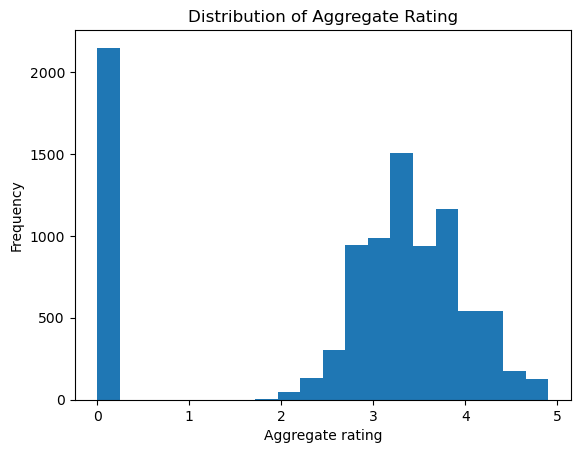

In [11]:
plt.hist(df["Aggregate rating"], bins=20)
plt.xlabel("Aggregate rating")
plt.ylabel("Frequency")
plt.title("Distribution of Aggregate Rating")
plt.show()

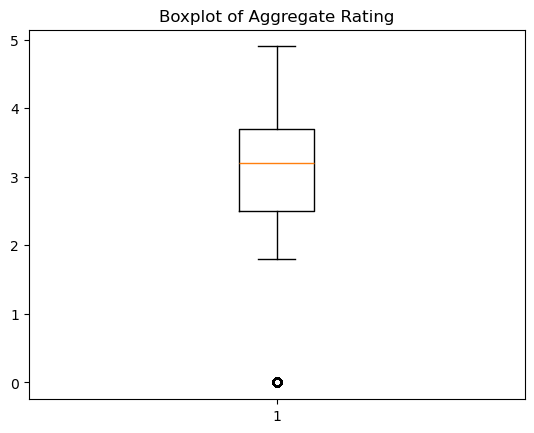

In [12]:
plt.boxplot(df["Aggregate rating"].dropna())
plt.title("Boxplot of Aggregate Rating")
plt.show()


In [13]:
df["Aggregate rating"].value_counts()

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64

In [14]:
df["Aggregate rating"].value_counts(normalize=True) * 100


Aggregate rating
0.0    22.489792
3.2     5.465396
3.1     5.433986
3.4     5.214114
3.3     5.057062
3.5     5.025652
3.0     4.900010
3.6     4.795309
3.7     4.470736
3.8     4.188043
2.9     3.989111
3.9     3.507486
2.8     3.298084
4.1     2.868810
4.0     2.785049
2.7     2.617527
4.2     2.313894
2.6     1.999791
4.3     1.821799
4.4     1.507696
2.5     1.151712
4.5     0.994660
2.4     0.910899
4.6     0.816668
4.9     0.638677
2.3     0.492095
4.7     0.439745
2.2     0.282693
4.8     0.261753
2.1     0.157052
2.0     0.073291
1.9     0.020940
1.8     0.010470
Name: proportion, dtype: float64

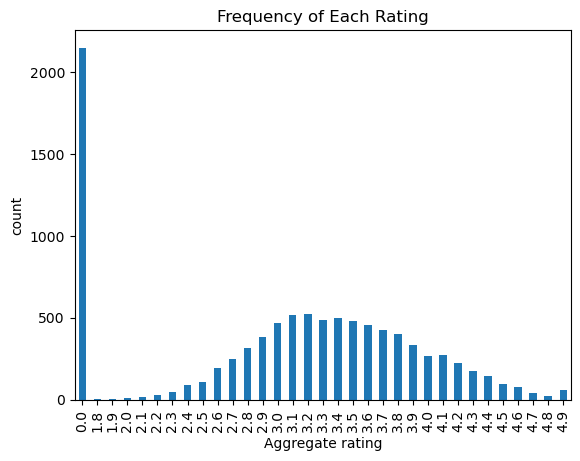

In [15]:
df["Aggregate rating"].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Aggregate rating")
plt.ylabel("count")
plt.title("Frequency of Each Rating")
plt.show()

it's Clearly visible that at [0.0] class imbalance exists

# Task 2 : -> Descriptive Analysis 

In [16]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [17]:
df.median(numeric_only = True)         # Median 

Restaurant ID           6.004089e+06
Country Code            1.000000e+00
Longitude               7.719196e+01
Latitude                2.857047e+01
Average Cost for two    4.000000e+02
Has Table booking       0.000000e+00
Has Online delivery     0.000000e+00
Is delivering now       0.000000e+00
Switch to order menu    0.000000e+00
Price range             2.000000e+00
Aggregate rating        3.200000e+00
Votes                   3.100000e+01
dtype: float64

In [18]:
df.std(numeric_only = True)                # Standard deviation

Restaurant ID           8.791521e+06
Country Code            5.675055e+01
Longitude               4.146706e+01
Latitude                1.100794e+01
Average Cost for two    1.612118e+04
Has Table booking       3.264275e-01
Has Online delivery     4.367920e-01
Is delivering now       5.956119e-02
Switch to order menu    0.000000e+00
Price range             9.056088e-01
Aggregate rating        1.516378e+00
Votes                   4.301691e+02
dtype: float64

In [19]:
df["Country Code"].value_counts()

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

In [20]:
df["City"].value_counts()

City
New Delhi           5473
Gurgaon             1118
Noida               1080
Faridabad            251
Ghaziabad             25
                    ... 
Trentham East          1
Weirton                1
Vineland Station       1
Winchester Bay         1
Yorkton                1
Name: count, Length: 141, dtype: int64

In [21]:
df["Cuisines"].value_counts()

Cuisines
North Indian                              936
North Indian, Chinese                     511
Chinese                                   354
Fast Food                                 354
North Indian, Mughlai                     334
                                         ... 
Turkish, Arabian, Middle Eastern            1
Turkish, Arabian, Moroccan, Lebanese        1
Turkish, Mediterranean, Middle Eastern      1
Vietnamese, Fish and Chips                  1
Western, Asian, Cafe                        1
Name: count, Length: 1825, dtype: int64

In [22]:
top_cuisines = df["Cuisines"].value_counts().head(10)                   # Top Cuisines
print(top_cuisines)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [23]:
top_cities = df["City"].value_counts().head(10)
print(top_cities)                                                       # Top Cities

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Ahmedabad         21
Amritsar          21
Name: count, dtype: int64


# Task 3 : --> Geospatial Analysis 

### Visualization of Map

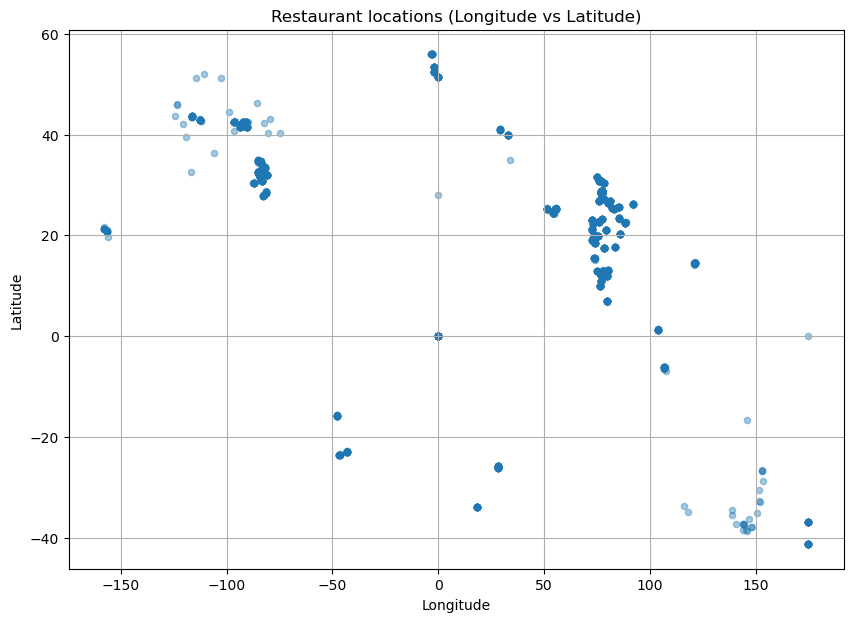

In [24]:
coords = df[["Longitude", "Latitude"]].dropna()

plt.figure(figsize=(10,7))
plt.scatter(coords["Longitude"], coords["Latitude"], s = 20, alpha = 0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant locations (Longitude vs Latitude)")
plt.grid(True)
plt.show()

In [25]:
import folium
from folium.plugins import MarkerCluster

center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

marker_cluster = MarkerCluster().add_to(m)

for _, row in df.dropna(subset=["Latitude", "Longitude"]).iterrows():
    popup_text = f"{row.get('Restaurant Name','')}<br>{row.get('Cuisines','')}"
    folium.Marker(location=[row["Latitude"], row["Longitude"]],
                  popup=popup_text).add_to(marker_cluster)

m.save("restaurants_map.html")
print("Saved interactive map -> restaurants_map.html")


Saved interactive map -> restaurants_map.html


### Distribution Of Resturants across Different cities

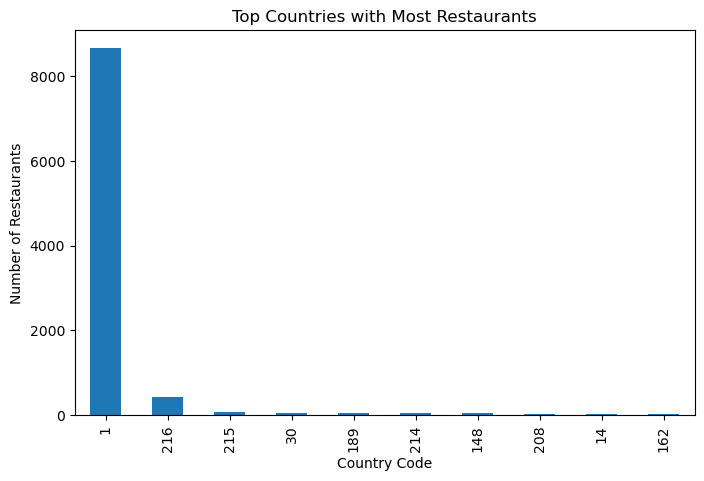

In [26]:
df["Country Code"].value_counts().head(10).plot(kind="bar", figsize=(8,5))
plt.title("Top Countries with Most Restaurants")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.show()


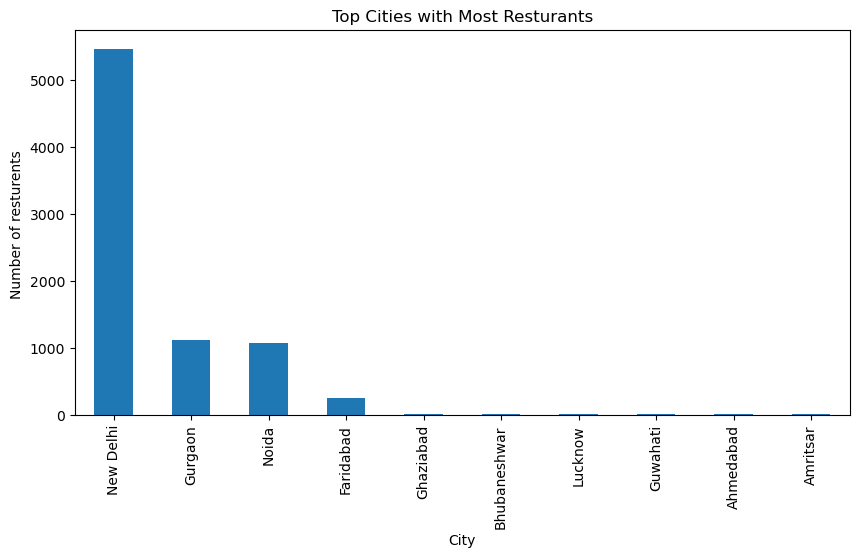

In [27]:
df["City"].value_counts().head(10).plot(kind = "bar", figsize = (10,5))
plt.title("Top Cities with Most Resturants")
plt.xlabel("City")
plt.ylabel("Number of resturents ")
plt.show()

### Correlation between Location & Rating

In [28]:
df[["Country Code", "Aggregate rating"]].corr()

,Country Code,Aggregate rating
Country Code,1.000000,0.282189
Aggregate rating,0.282189,1.000000


<Figure size 1200x600 with 0 Axes>

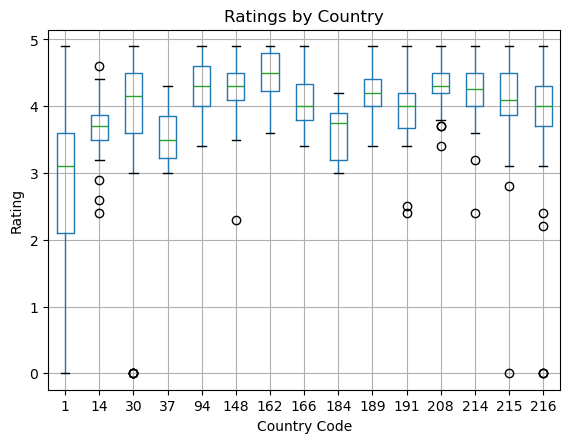

In [29]:
plt.figure(figsize=(12,6))
df.boxplot(column="Aggregate rating", by="Country Code")
plt.title("Ratings by Country")
plt.suptitle("")
plt.xlabel("Country Code")
plt.ylabel("Rating")
plt.show()

#### This is a possible correlation but it's not much efficient as many resturents may have same country code 

## ==========================================================================

# We have the categorial columns related to Locations , I have to perform these three operations here 
## 1. Label Encoding 
## 2. One Hot Encoding 
## 3. Grpoup Mean Analysis

### =====================================================================================

### 1. Label Encoding 

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City_encoded'] = le.fit_transform(df['City'])
df['Locality_encoded'] = le.fit_transform(df['Locality'])

In [31]:
df[['Aggregate rating','City_encoded','Locality_encoded']].corr()

,Aggregate rating,City_encoded,Locality_encoded
Aggregate rating,1.000000,-0.132163,-0.174336
City_encoded,-0.132163,1.000000,0.096443
Locality_encoded,-0.174336,0.096443,1.000000


### 2. One Hot Encoding

In [32]:
df_encoded = pd.get_dummies(df, columns=['City','Locality'], drop_first=True)

In [43]:
df_encoded    # new data Frame with dummy columns ** But in character values 

,Restaurant ID,Restaurant Name,Country Code,Address,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,...,Locality_Yusuf Sarai,Locality_Y۱ld۱zevler,"Locality_Z Square Mall, Mall Road",Locality_Zakir Nagar,Locality_Zoo Tiniali,"Locality_ibis New Delhi, Aerocity",Locality_�ayyolu,Locality_�guas Claras,Locality_�ukurambar,Locality_��mitk�_y
0,6317637,Le Petit Souffle,162,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
1,6304287,Izakaya Kikufuji,162,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
2,6300002,Heat - Edsa Shangri-La,162,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
3,6318506,Ooma,162,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
4,6314302,Sambo Kojin,162,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...","Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9547,5908749,Ceviz A��ac۱,208,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...","Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9548,5915807,Huqqa,208,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...","Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9549,5916112,A���k Kahve,208,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...","Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0


In [34]:
print(df_encoded.shape)

(9551, 1368)


In [35]:
df_encoded = df_encoded.applymap(lambda x: int(x) if isinstance(x, bool) else x)

C:\Users\Arka Patra\AppData\Local\Temp\ipykernel_33828\2545532890.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_encoded = df_encoded.applymap(lambda x: int(x) if isinstance(x, bool) else x)


In [46]:
df_encoded            # true -> 1 ; False -> 0 

,Restaurant ID,Restaurant Name,Country Code,Address,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,...,Locality_Yusuf Sarai,Locality_Y۱ld۱zevler,"Locality_Z Square Mall, Mall Road",Locality_Zakir Nagar,Locality_Zoo Tiniali,"Locality_ibis New Delhi, Aerocity",Locality_�ayyolu,Locality_�guas Claras,Locality_�ukurambar,Locality_��mitk�_y
0,6317637,Le Petit Souffle,162,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
1,6304287,Izakaya Kikufuji,162,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
2,6300002,Heat - Edsa Shangri-La,162,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
3,6318506,Ooma,162,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
4,6314302,Sambo Kojin,162,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...","Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9547,5908749,Ceviz A��ac۱,208,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...","Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9548,5915807,Huqqa,208,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...","Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0
9549,5916112,A���k Kahve,208,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...","Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),...,0,0,0,0,0,0,0,0,0,0


In [47]:
location_cols = [col for col in df_encoded.columns if col.startswith('City_') or col.startswith('Locality_')]

loc_corr = df_encoded[location_cols + ['Aggregate rating']].corr()['Aggregate rating'].sort_values(ascending=False)
loc_corr


Aggregate rating                   1.000000
Locality_Connaught Place           0.076556
Locality_Rajouri Garden            0.062470
Locality_Greater Kailash (GK) 1    0.056697
City_London                        0.056453
                                     ...   
City_encoded                      -0.132163
Locality_Najafgarh                -0.137281
City_Noida                        -0.148394
City_New Delhi                    -0.173833
Locality_encoded                  -0.174336
Name: Aggregate rating, Length: 1350, dtype: float64

## Yes There is a correlation between Aggregrate rating and Location , But trhe correlation is very week . Linke in a range of 0.07 - (-.17)

# __________________________________________________________________________________

# Level 2

## Task 1